
# Brain Tumor Classification using CNN and Transfer Learning

## 6CS012 Final Portfolio Project – Part II (Vision Task)





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Basic Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Output
print("Libraries imported successfully")


Libraries imported successfully



# 1. Dataset Understanding and Visualization


In [ ]:

# Dataset path
dataset_path = '/content/drive/MyDrive/AI and Machine Learning/Assessment_Part2/Brain Tumor Classifcation'

train_path = os.path.join(dataset_path, 'train')
test_path = os.path.join(dataset_path, 'test')

# Output
print("Train Path:", train_path)
# Output
print("Test Path:", test_path)


Train Path: /content/drive/MyDrive/AI and Machine Learning/Assessment_Part2/Brain Tumor Classifcation/train
Test Path: /content/drive/MyDrive/AI and Machine Learning/Assessment_Part2/Brain Tumor Classifcation/test


In [ ]:

# Count images in each class

classes = os.listdir(train_path)

train_count = {}
test_count = {}

for cls in classes:
    train_count[cls] = len(os.listdir(os.path.join(train_path, cls)))
    test_count[cls] = len(os.listdir(os.path.join(test_path, cls)))

train_df = pd.DataFrame({
    'Class': list(train_count.keys()),
    'Train Images': list(train_count.values()),
    'Test Images': list(test_count.values())
})

train_df['Total'] = train_df['Train Images'] + train_df['Test Images']

train_df


,Class,Train Images,Test Images,Total
0,glioma_tumor,713,181,894
1,meningioma_tumor,723,183,906
2,normal,343,88,431
3,pituitary_tumor,668,169,837


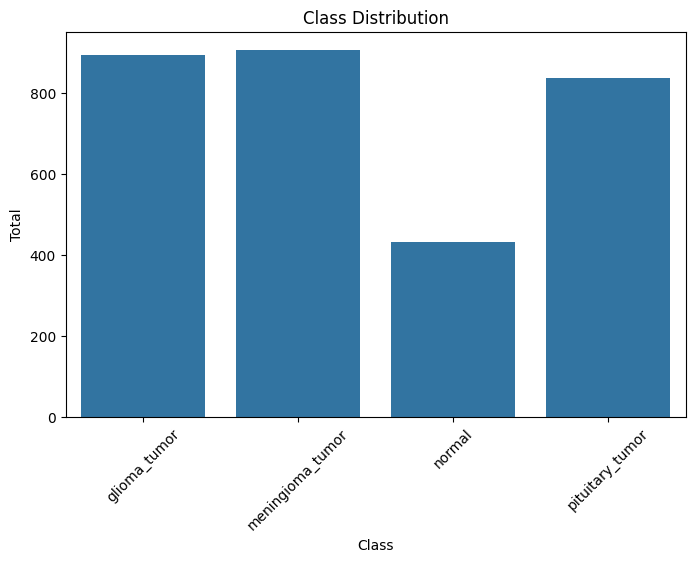

In [ ]:
import seaborn as sns

# Visualize class distribution

plt.figure(figsize=(8,5))
sns.barplot(x='Class', y='Total', data=train_df)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

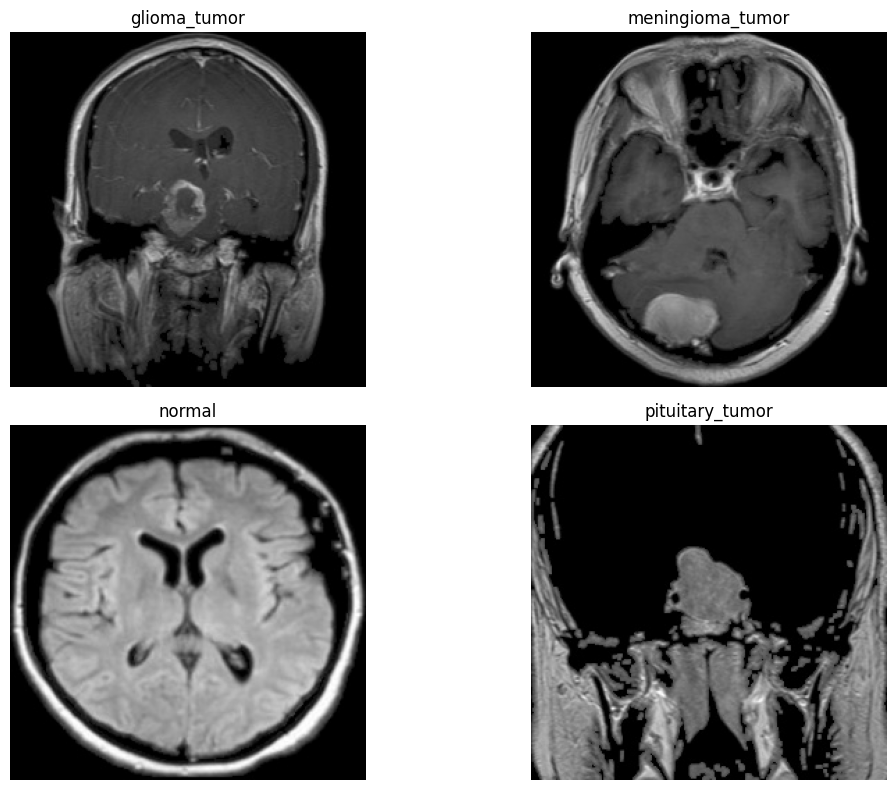

In [ ]:

# Display sample images

plt.figure(figsize=(12,8))

for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(train_path, cls))[0]
    img_path = os.path.join(train_path, cls, img_name)

    img = plt.imread(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()



# 2. Data Preprocessing and Augmentation


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = len(train_generator.class_indices)
# Output
print("Number of Classes:", num_classes)

Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.
Number of Classes: 4


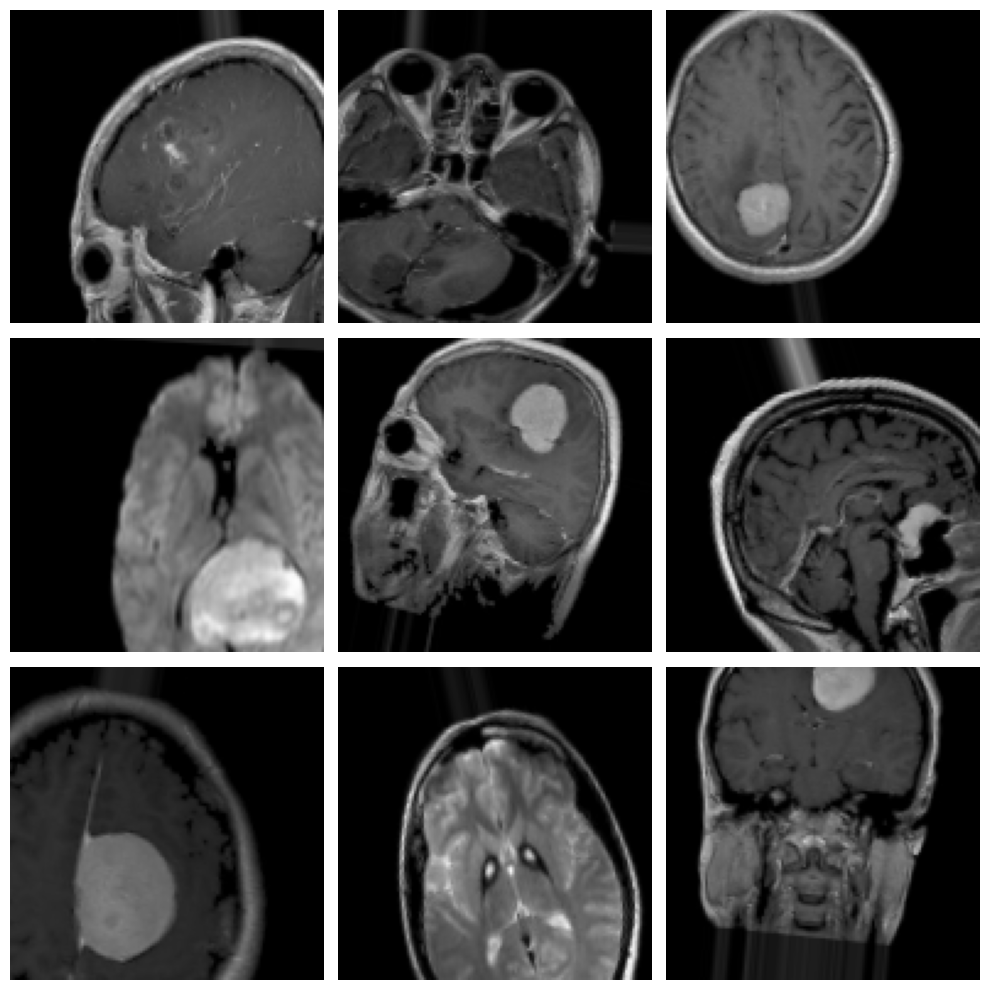

In [ ]:

# Visualize augmented images

images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()



# 3. Baseline CNN Model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,557,444 (25.01 MB)

 Trainable params: 6,557,444 (25.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import time

# Train baseline model

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[early_stop]
)

baseline_time = time.time() - start_time

# Output
print("Training Time:", baseline_time)

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 1367s 22s/step - accuracy: 0.2893 - loss: 1.3761 - val_accuracy: 0.3162 - val_loss: 1.3536
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.3184 - loss: 1.3333 - val_accuracy: 0.4476 - val_loss: 1.2207
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.4010 - loss: 1.2402 - val_accuracy: 0.4456 - val_loss: 1.2089
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.4332 - loss: 1.2001 - val_accuracy: 0.5092 - val_loss: 1.1175
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.4735 - loss: 1.1412 - val_accuracy: 0.4702 - val_loss: 1.0545
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.4867 - loss: 1.1191 - val_accuracy: 0.4825 - val_loss: 1.1136
Epoch 7/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.5566 - loss: 1.0132 - val_accuracy: 0.4969 - val_loss: 1.1338
Epoch 8/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.5653 - loss: 0.9824 - val_accuracy: 0.5483 - val_

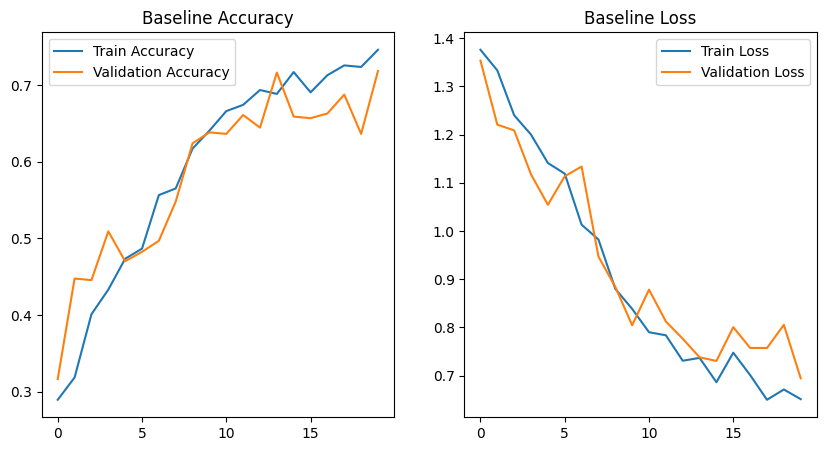

In [ ]:

# Plot accuracy and loss

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_baseline.history['accuracy'], label='Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Baseline Accuracy')

plt.subplot(1,2,2)
plt.plot(history_baseline.history['loss'], label='Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Baseline Loss')

plt.show()


In [ ]:
from sklearn.metrics import classification_report

# Evaluate baseline model

baseline_preds = baseline_model.predict(test_generator)
baseline_pred_classes = np.argmax(baseline_preds, axis=1)

true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Output
print(classification_report(true_classes, baseline_pred_classes, target_names=class_labels))

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 535ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.91      0.41      0.56       181
meningioma_tumor       0.63      0.34      0.44       183
          normal       0.87      0.53      0.66        88
 pituitary_tumor       0.44      1.00      0.61       169

        accuracy                           0.57       621
       macro avg       0.71      0.57      0.57       621
    weighted avg       0.69      0.57      0.55       621



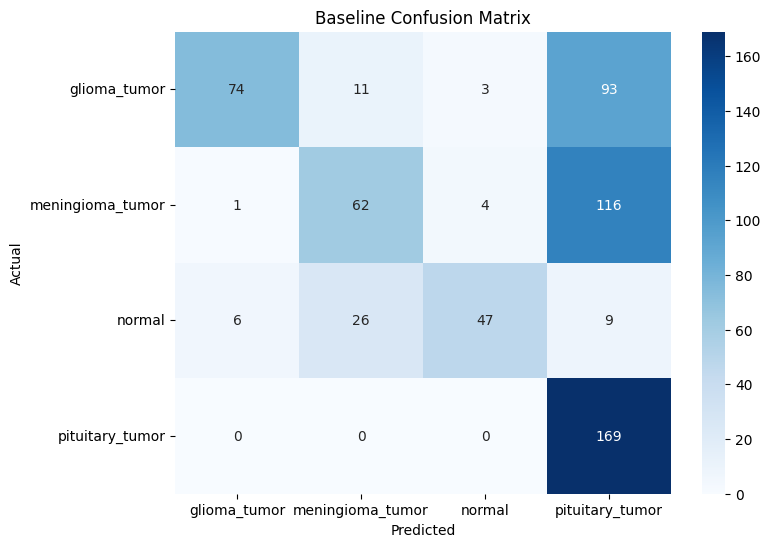

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix

cm = confusion_matrix(true_classes, baseline_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Confusion Matrix")
plt.show()


# 4. Deeper CNN with Regularization


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

deep_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

deep_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 2,786,372 (10.63 MB)

 Trainable params: 2,784,388 (10.62 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:

# Train deeper model

start_time = time.time()

history_deep = deep_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=25,
    callbacks=[early_stop]
)

deep_time = time.time() - start_time

# Output
print("Training Time:", deep_time)


Epoch 1/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.3811 - loss: 1.4264 - val_accuracy: 0.3963 - val_loss: 1.3646
Epoch 2/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.4128 - loss: 1.3238 - val_accuracy: 0.3491 - val_loss: 1.5309
Epoch 3/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.4214 - loss: 1.2659 - val_accuracy: 0.3573 - val_loss: 1.5237
Epoch 4/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 157s 3s/step - accuracy: 0.4811 - loss: 1.1733 - val_accuracy: 0.3799 - val_loss: 1.3110
Epoch 5/25
62/62 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.5092 - loss: 1.1189 - val_accuracy: 0.4148 - val_loss: 1.1824
Training Time: 781.5179545879364


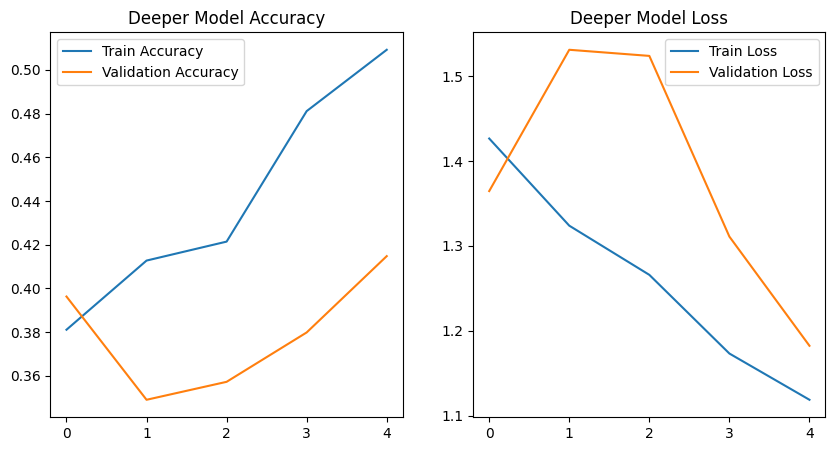

In [ ]:

# Plot deeper model performance

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(history_deep.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Deeper Model Accuracy')

plt.subplot(1,2,2)
plt.plot(history_deep.history['loss'], label='Train Loss')
plt.plot(history_deep.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Deeper Model Loss')

plt.show()


In [ ]:

# Evaluate deeper model

deep_preds = deep_model.predict(test_generator)
deep_pred_classes = np.argmax(deep_preds, axis=1)

# Output
print(classification_report(true_classes, deep_pred_classes, target_names=class_labels))


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 449ms/step
                  precision    recall  f1-score   support

    glioma_tumor       0.35      0.77      0.48       181
meningioma_tumor       0.42      0.49      0.45       183
          normal       0.40      0.02      0.04        88
 pituitary_tumor       0.00      0.00      0.00       169

        accuracy                           0.37       621
       macro avg       0.29      0.32      0.24       621
    weighted avg       0.28      0.37      0.28       621



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



# 5. Optimizer Comparison: SGD vs Adam


In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import SGD

# Deep model with SGD

deep_model_sgd = tf.keras.models.clone_model(deep_model)

deep_model_sgd.compile(
    optimizer=SGD(learning_rate=0.001, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deep_model_sgd.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.3270 - loss: 1.7247 - val_accuracy: 0.3121 - val_loss: 1.3743
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.3974 - loss: 1.3263 - val_accuracy: 0.3121 - val_loss: 1.4031
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.3990 - loss: 1.2865 - val_accuracy: 0.3306 - val_loss: 1.3820
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.4296 - loss: 1.2282 - val_accuracy: 0.3388 - val_loss: 1.4885
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.4689 - loss: 1.1726 - val_accuracy: 0.3634 - val_loss: 1.5185
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.4929 - loss: 1.1423 - val_accuracy: 0.3758 - val_loss: 1.3976
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.5097 - loss: 1.1020 - val_accuracy: 0.3819 - val_loss: 1.5070
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5490 - loss: 1.0435 - val_accuracy: 0.3737 - v

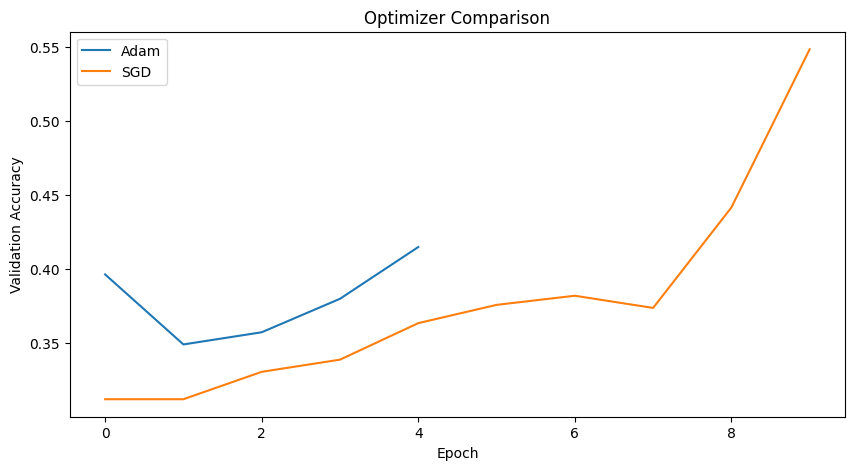

In [ ]:

# Compare optimizers

plt.figure(figsize=(10,5))

plt.plot(history_deep.history['val_accuracy'], label='Adam')
plt.plot(history_sgd.history['val_accuracy'], label='SGD')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()



# 6. Ablation Study (Without Dropout)


In [ ]:

ablation_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),
    Dense(128, activation='relu'),

    Dense(num_classes, activation='softmax')
])

ablation_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.2944 - loss: 1.3747 - val_accuracy: 0.2957 - val_loss: 1.3615
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.3235 - loss: 1.3377 - val_accuracy: 0.4107 - val_loss: 1.2852
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.4240 - loss: 1.2301 - val_accuracy: 0.5339 - val_loss: 1.1108
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.4837 - loss: 1.1440 - val_accuracy: 0.5154 - val_loss: 1.1022
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.5444 - loss: 1.0551 - val_accuracy: 0.5400 - val_loss: 0.9799
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.5760 - loss: 0.9843 - val_accuracy: 0.5791 - val_loss: 0.9555
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.6107 - loss: 0.9093 - val_accuracy: 0.5975 - val_loss: 0.8992
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.6245 - loss: 0.8589 - val_accuracy: 0.6242 - val_l


# Observation

Removing dropout may increase training accuracy but can lead to overfitting because the model memorizes training samples instead of generalizing.



# 7. Transfer Learning using MobileNetV2


In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators for transfer learning

train_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen_tl = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_gen_tl = train_datagen_tl.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_gen_tl = test_datagen_tl.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1960 images belonging to 4 classes.
Found 487 images belonging to 4 classes.
Found 621 images belonging to 4 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load pretrained MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(num_classes, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=outputs)

transfer_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

# Train transfer learning model

history_transfer = transfer_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.4301 - loss: 1.3533 - val_accuracy: 0.6571 - val_loss: 0.9164
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.6566 - loss: 0.8596 - val_accuracy: 0.7125 - val_loss: 0.7374
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.7005 - loss: 0.7191 - val_accuracy: 0.7639 - val_loss: 0.6688
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.7582 - loss: 0.6143 - val_accuracy: 0.7967 - val_loss: 0.6113
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.7872 - loss: 0.5472 - val_accuracy: 0.7885 - val_loss: 0.5867
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.8087 - loss: 0.4991 - val_accuracy: 0.8152 - val_loss: 0.5459
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8194 - loss: 0.4598 - val_accuracy: 0.8111 - val_loss: 0.5092
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.8342 - loss: 0.4272 - val_accuracy: 0.8255 - v

In [ ]:

# Fine tuning

base_model.trainable = True

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = transfer_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=5
)


Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 561s 8s/step - accuracy: 0.6495 - loss: 0.8801 - val_accuracy: 0.8172 - val_loss: 0.4763
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 512s 8s/step - accuracy: 0.7541 - loss: 0.6317 - val_accuracy: 0.8172 - val_loss: 0.4858
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 506s 8s/step - accuracy: 0.8128 - loss: 0.5066 - val_accuracy: 0.8172 - val_loss: 0.5018
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 485s 8s/step - accuracy: 0.8337 - loss: 0.4248 - val_accuracy: 0.8070 - val_loss: 0.5233
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 485s 8s/step - accuracy: 0.8781 - loss: 0.3659 - val_accuracy: 0.7988 - val_loss: 0.5516


In [ ]:

# Evaluate transfer learning model

transfer_preds = transfer_model.predict(test_gen_tl)
transfer_pred_classes = np.argmax(transfer_preds, axis=1)

# Output
print(classification_report(
    test_gen_tl.classes,
    transfer_pred_classes,
    target_names=class_labels
))


20/20 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step
                  precision    recall  f1-score   support

    glioma_tumor       0.89      0.77      0.83       181
meningioma_tumor       0.78      0.78      0.78       183
          normal       0.77      0.97      0.86        88
 pituitary_tumor       0.88      0.89      0.88       169

        accuracy                           0.83       621
       macro avg       0.83      0.85      0.84       621
    weighted avg       0.84      0.83      0.83       621




# 8. Model Comparison


In [ ]:

comparison = pd.DataFrame({
    'Model': ['Baseline CNN', 'Deep CNN', 'Transfer Learning'],
    'Training Time': [baseline_time, deep_time, 'Depends on hardware'],
})

comparison


,Model,Training Time
0,Baseline CNN,3517.82233
1,Deep CNN,781.517955
2,Transfer Learning,Depends on hardware



# 9. Sample Predictions


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step


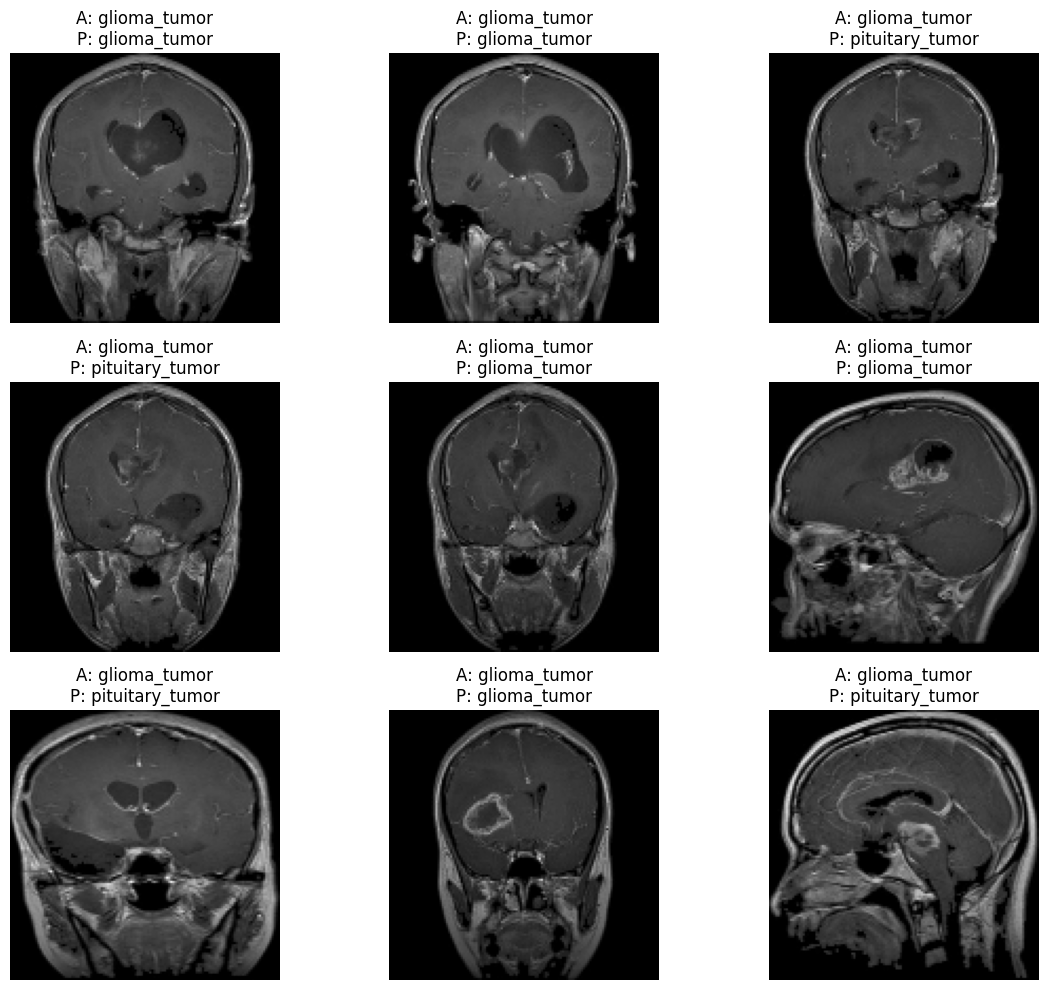

In [ ]:

# Predict sample images

sample_images, sample_labels = next(test_generator)

predictions = baseline_model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(sample_images[i])

    actual = class_labels[np.argmax(sample_labels[i])]
    predicted = class_labels[predicted_classes[i]]

    plt.title(f"A: {actual}\nP: {predicted}")
    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()



# 10. Final Observations and Conclusion

## Key Findings
- The deeper CNN achieved better performance than the baseline CNN.
- Batch Normalization and Dropout improved generalization.
- Adam optimizer converged faster than SGD.
- Transfer learning using MobileNetV2 produced the best overall performance.
- Fine-tuning improved feature adaptation for brain tumor classification.

## Challenges Faced
- Overfitting in deeper networks
- Longer training time
- Hardware limitations without GPU

## Future Improvements
- Use larger datasets
- Apply hyperparameter tuning
- Experiment with EfficientNet and ResNet
- Use advanced augmentation techniques



# Additional Visualizations
These visualizations include:
- Dataset class distribution
- Accuracy curves
- Loss curves
- Confusion matrix
- Prediction visualization


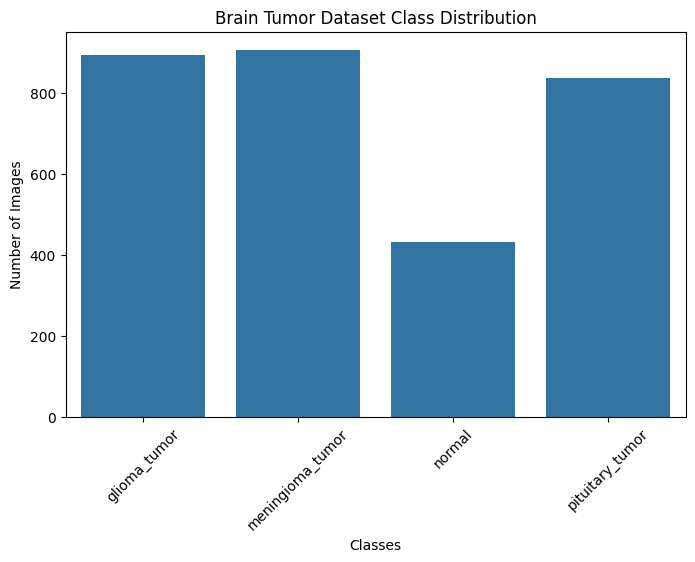

In [ ]:

# Dataset Visualization

plt.figure(figsize=(8,5))

sns.barplot(
    x=train_df['Class'],
    y=train_df['Total']
)

plt.title("Brain Tumor Dataset Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.show()


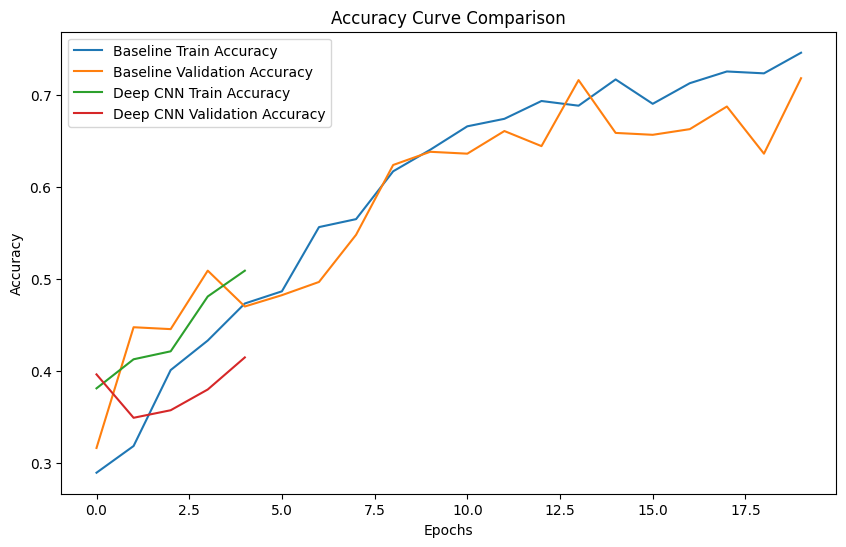

In [ ]:

# Accuracy Curve Comparison

plt.figure(figsize=(10,6))

plt.plot(history_baseline.history['accuracy'], label='Baseline Train Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Validation Accuracy')

plt.plot(history_deep.history['accuracy'], label='Deep CNN Train Accuracy')
plt.plot(history_deep.history['val_accuracy'], label='Deep CNN Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve Comparison")
plt.legend()

plt.show()


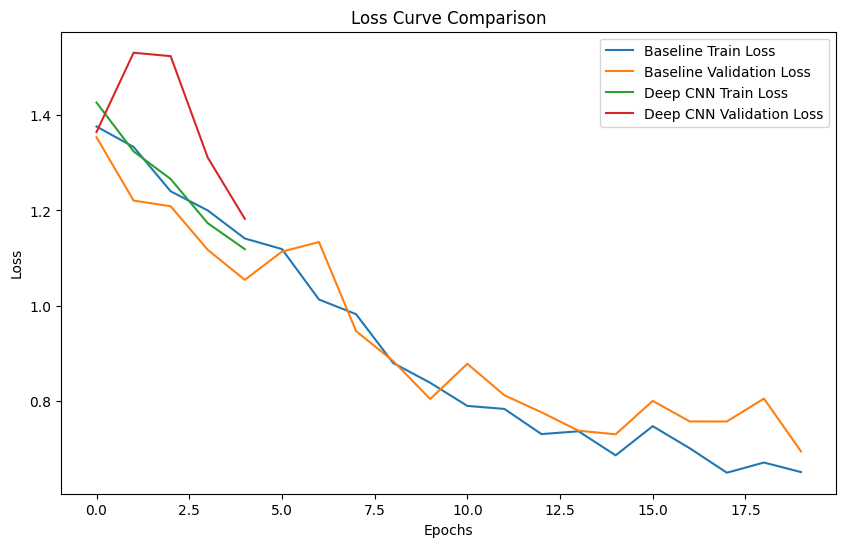

In [ ]:

# Loss Curve Comparison

plt.figure(figsize=(10,6))

plt.plot(history_baseline.history['loss'], label='Baseline Train Loss')
plt.plot(history_baseline.history['val_loss'], label='Baseline Validation Loss')

plt.plot(history_deep.history['loss'], label='Deep CNN Train Loss')
plt.plot(history_deep.history['val_loss'], label='Deep CNN Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve Comparison")
plt.legend()

plt.show()


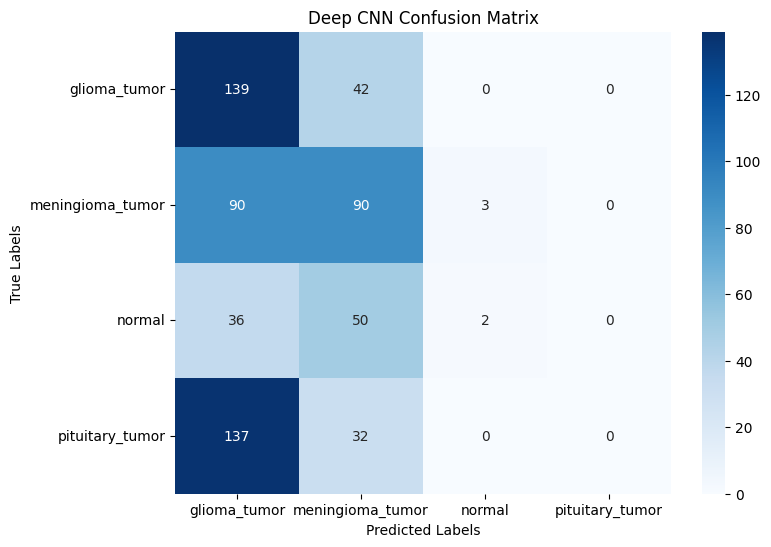

In [ ]:

# Confusion Matrix for Deep CNN

deep_cm = confusion_matrix(true_classes, deep_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    deep_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Deep CNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 688ms/step


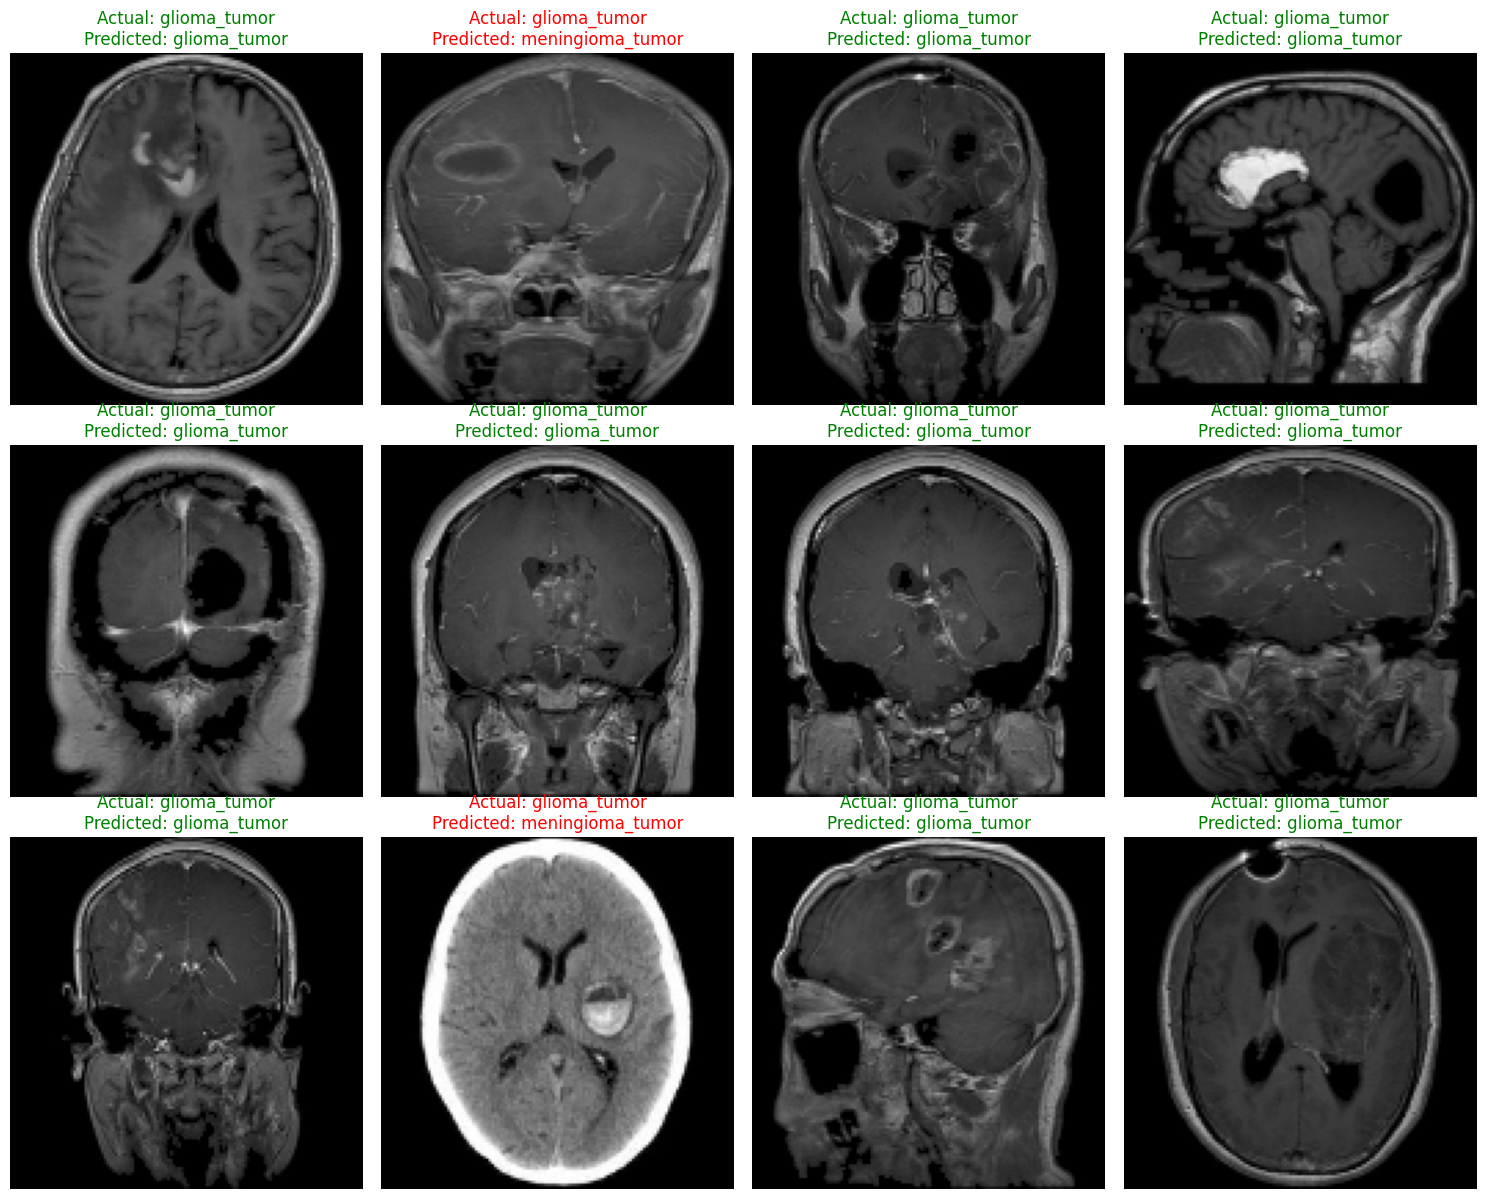

In [ ]:

# Visualize Predictions

sample_images, sample_labels = next(test_generator)

predictions = deep_model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(15,12))

for i in range(12):

    plt.subplot(3,4,i+1)

    plt.imshow(sample_images[i])

    actual_label = class_labels[np.argmax(sample_labels[i])]
    predicted_label = class_labels[predicted_classes[i]]

    if actual_label == predicted_label:
        color = 'green'
    else:
        color = 'red'

    plt.title(
        f"Actual: {actual_label}\nPredicted: {predicted_label}",
        color=color
    )

    plt.axis('off')

# Adjust layout
plt.tight_layout()
plt.show()
